In [3]:
import pandas as pd
import gensim
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import numpy as np


  Could not find a version that satisfies the requirement genism (from versions: )
No matching distribution found for genism


ModuleNotFoundError: No module named 'gensim'

In [1]:

stops = set(stopwords.words("english"))
lemma = nltk.stem.WordNetLemmatizer()


NameError: name 'stopwords' is not defined

In [4]:
df = pd.read_excel("sms-data.xls", sheet_name='Sheet1')

In [5]:
debits = df[df['class'] == 'DEBIT']
sentences = list(debits['Body'])
credits = df[df['class'] == 'CREDIT']
sentences.extend(list(credits['Body']))

In [6]:
dataset = []
for i in sentences:
    nltk_tokens = nltk.word_tokenize(i.lower())
    dataset.append([w for w in nltk_tokens if not w in stops])

# dataset = np.array(dataset)
# dataset

In [7]:
model = gensim.models.Word2Vec(dataset)

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: DeprecationWarning: Call to deprecated `__getitem__` (Method will be removed in 4.0.0, use self.wv.__getitem__() instead).
  """


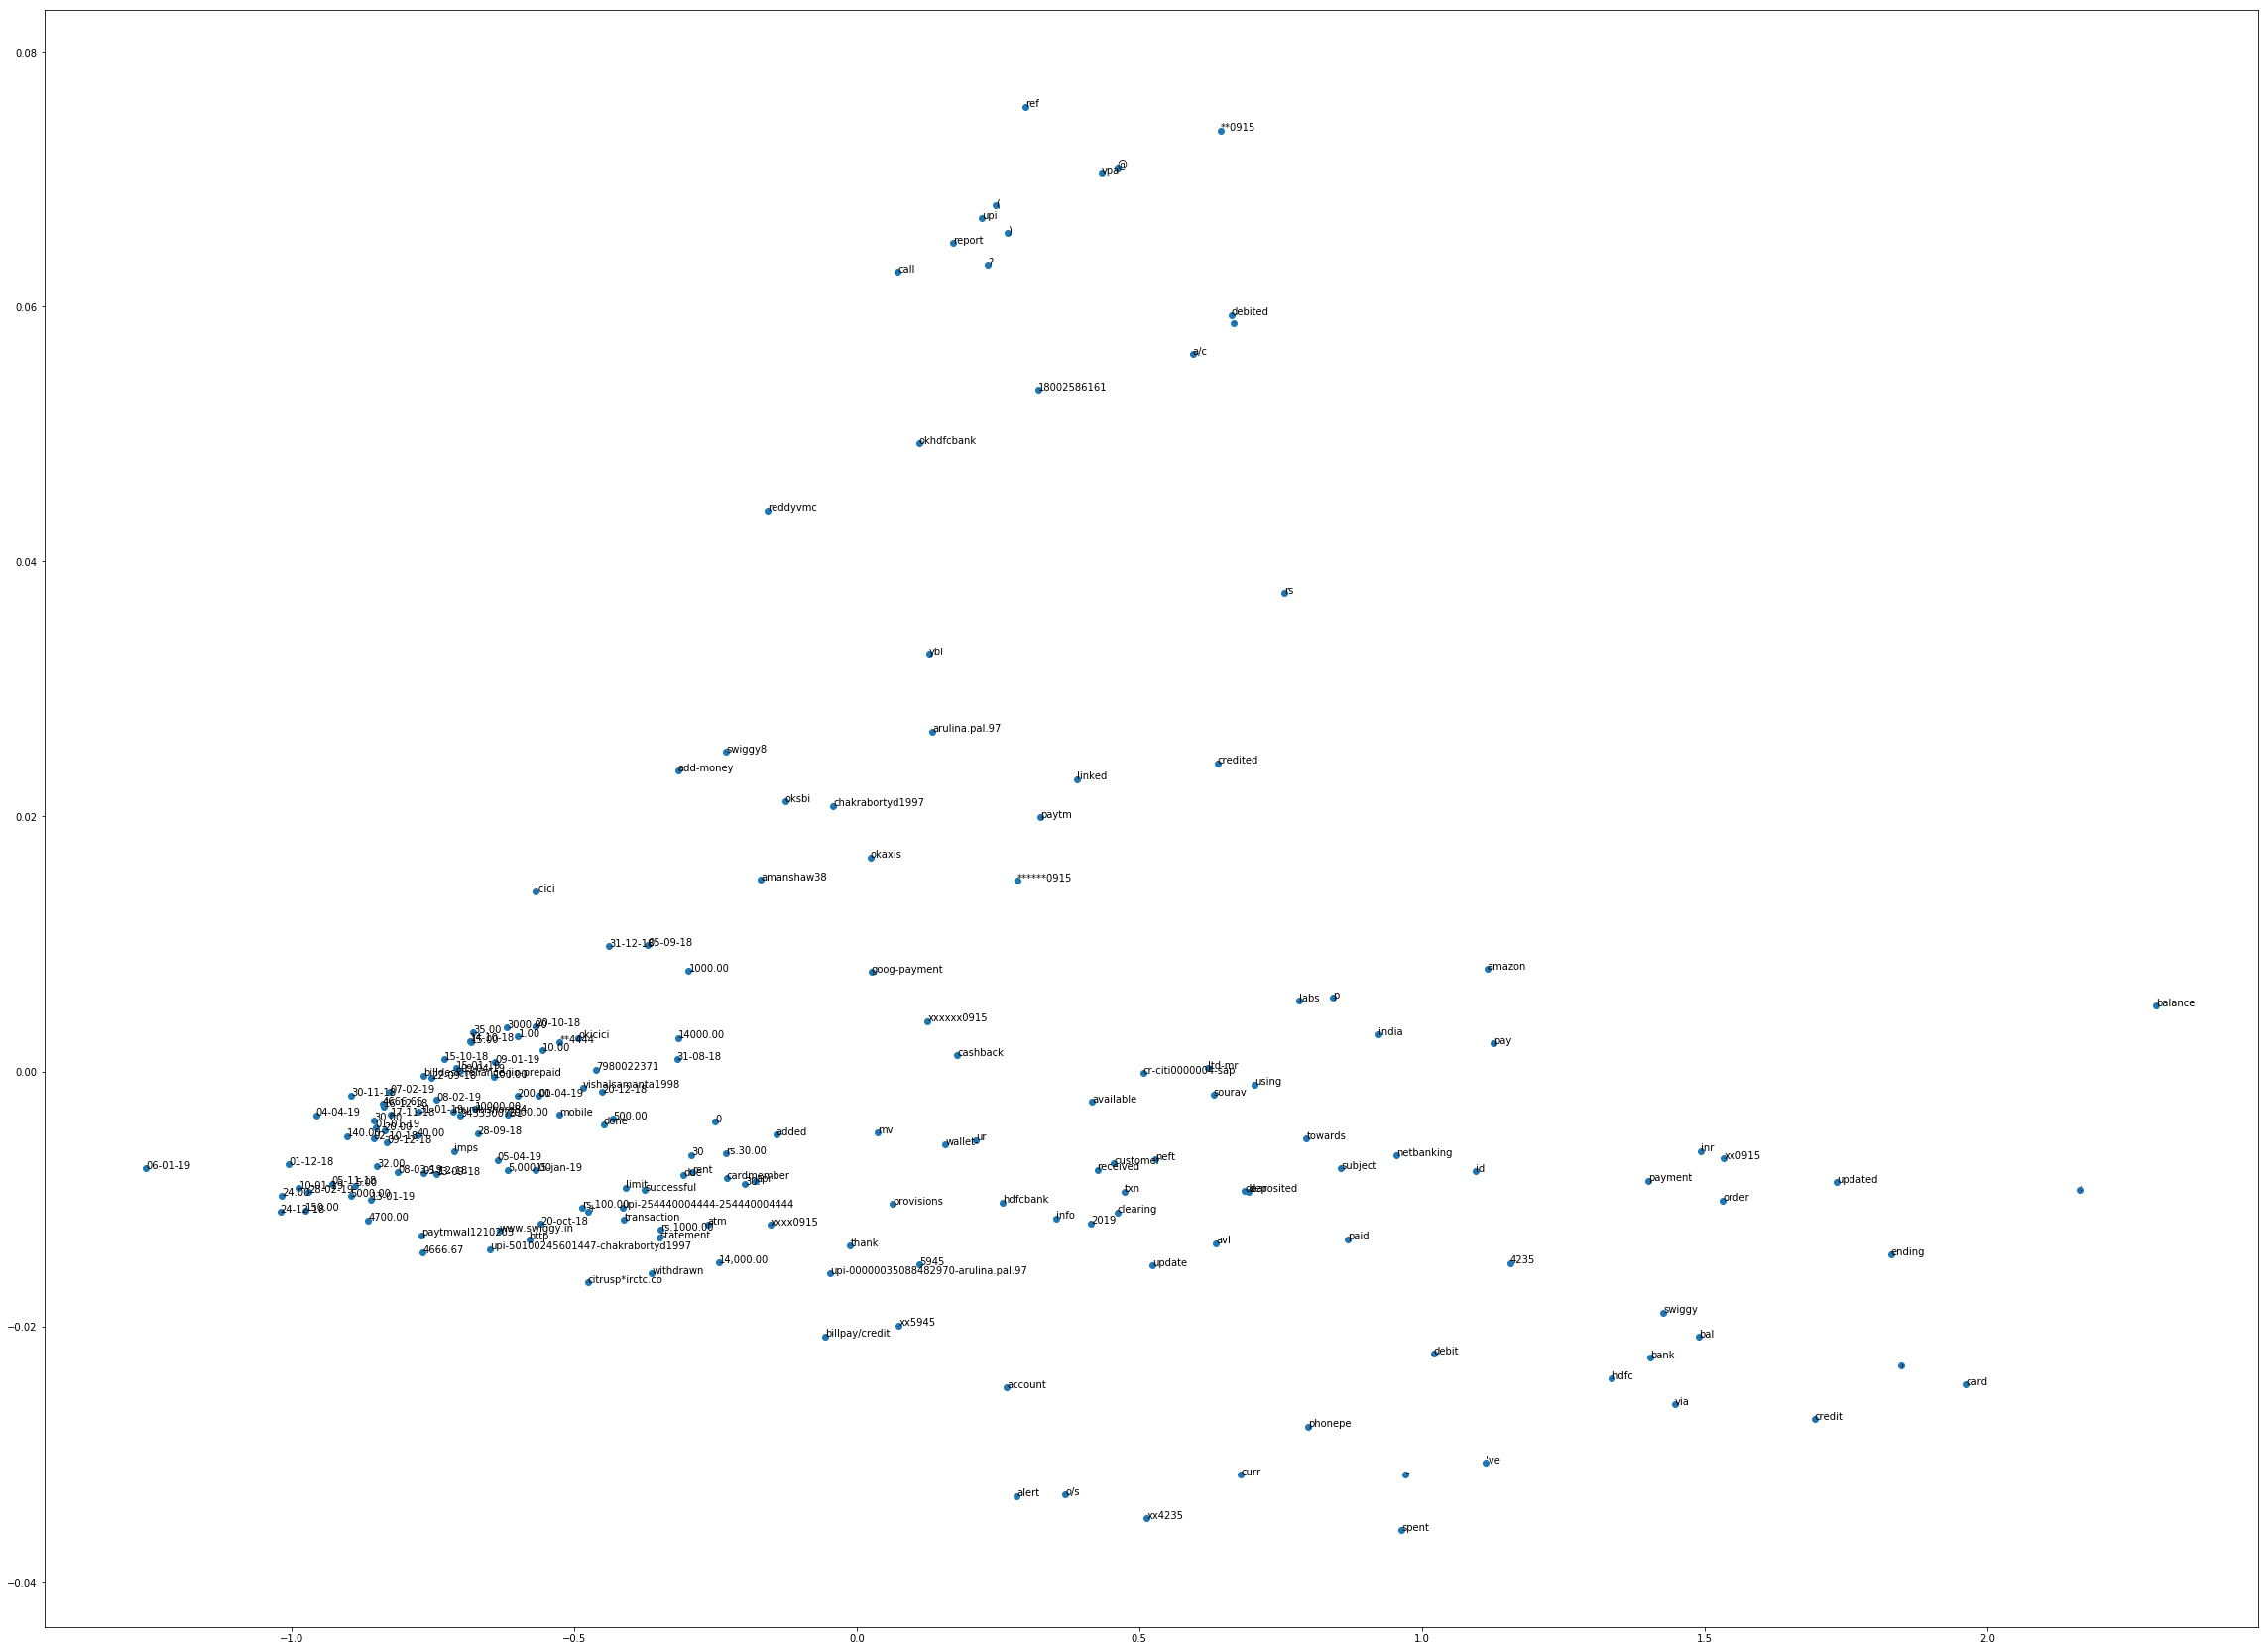

In [9]:
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from matplotlib import pyplot

X = model[model.wv.vocab]
# print(model['debit'])

pca = PCA(n_components=2)
result = pca.fit_transform(X)

pyplot.figure(figsize=(40,30))
pyplot.scatter(result[:, 0], result[:, 1])

words = list(model.wv.vocab)
for i, word in enumerate(words):
    pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))
pyplot.show()

In [ ]:
X